In [7]:
import cogsworth
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

In [8]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [9]:
files = ["fiducial", "fryer_rapid", "mandel_muller", 'maltsev_fallback_0.0', 'maltsev_fallback_0.25',
         'maltsev_fallback_0.5', 'maltsev_fallback_0.75', 'maltsev_fallback_1.0',
         'maltsev_pf_prob_0.0', 'maltsev_pf_prob_1.0']
labels = ["Fryer+12 (Delayed)", "Fryer+12 (Rapid)", "Mandel & Muller 2020", r"Maltsev+25 ($f_{\rm fb}=0.0$)",
          r"Maltsev+25 ($f_{\rm fb}=0.25$)", r"Maltsev+25 ($f_{\rm fb}=0.5$)", r"Maltsev+25 ($f_{\rm fb}=0.75$)",
          r"Maltsev+25 ($f_{\rm fb}=1.0$)", r"Maltsev+25 ($P({\rm pf})=0.0$)", r"Maltsev+25 ($P({\rm pf})=1.0$)"]    
colours = ["#333", "slategrey", "dodgerblue"]

# add five colours from the "Reds" colormap, and two from the "Yellows" colormap
colours.extend([plt.get_cmap("Reds", 6)(i) for i in range(1, 6)])
colours.extend([plt.get_cmap("RdPu", 5)(i) for i in range(2, 4)])

In [10]:
reload(helpers)
pops, data = helpers.load_postprocessed_pops(
    files=files, labels=labels, colours=colours
)

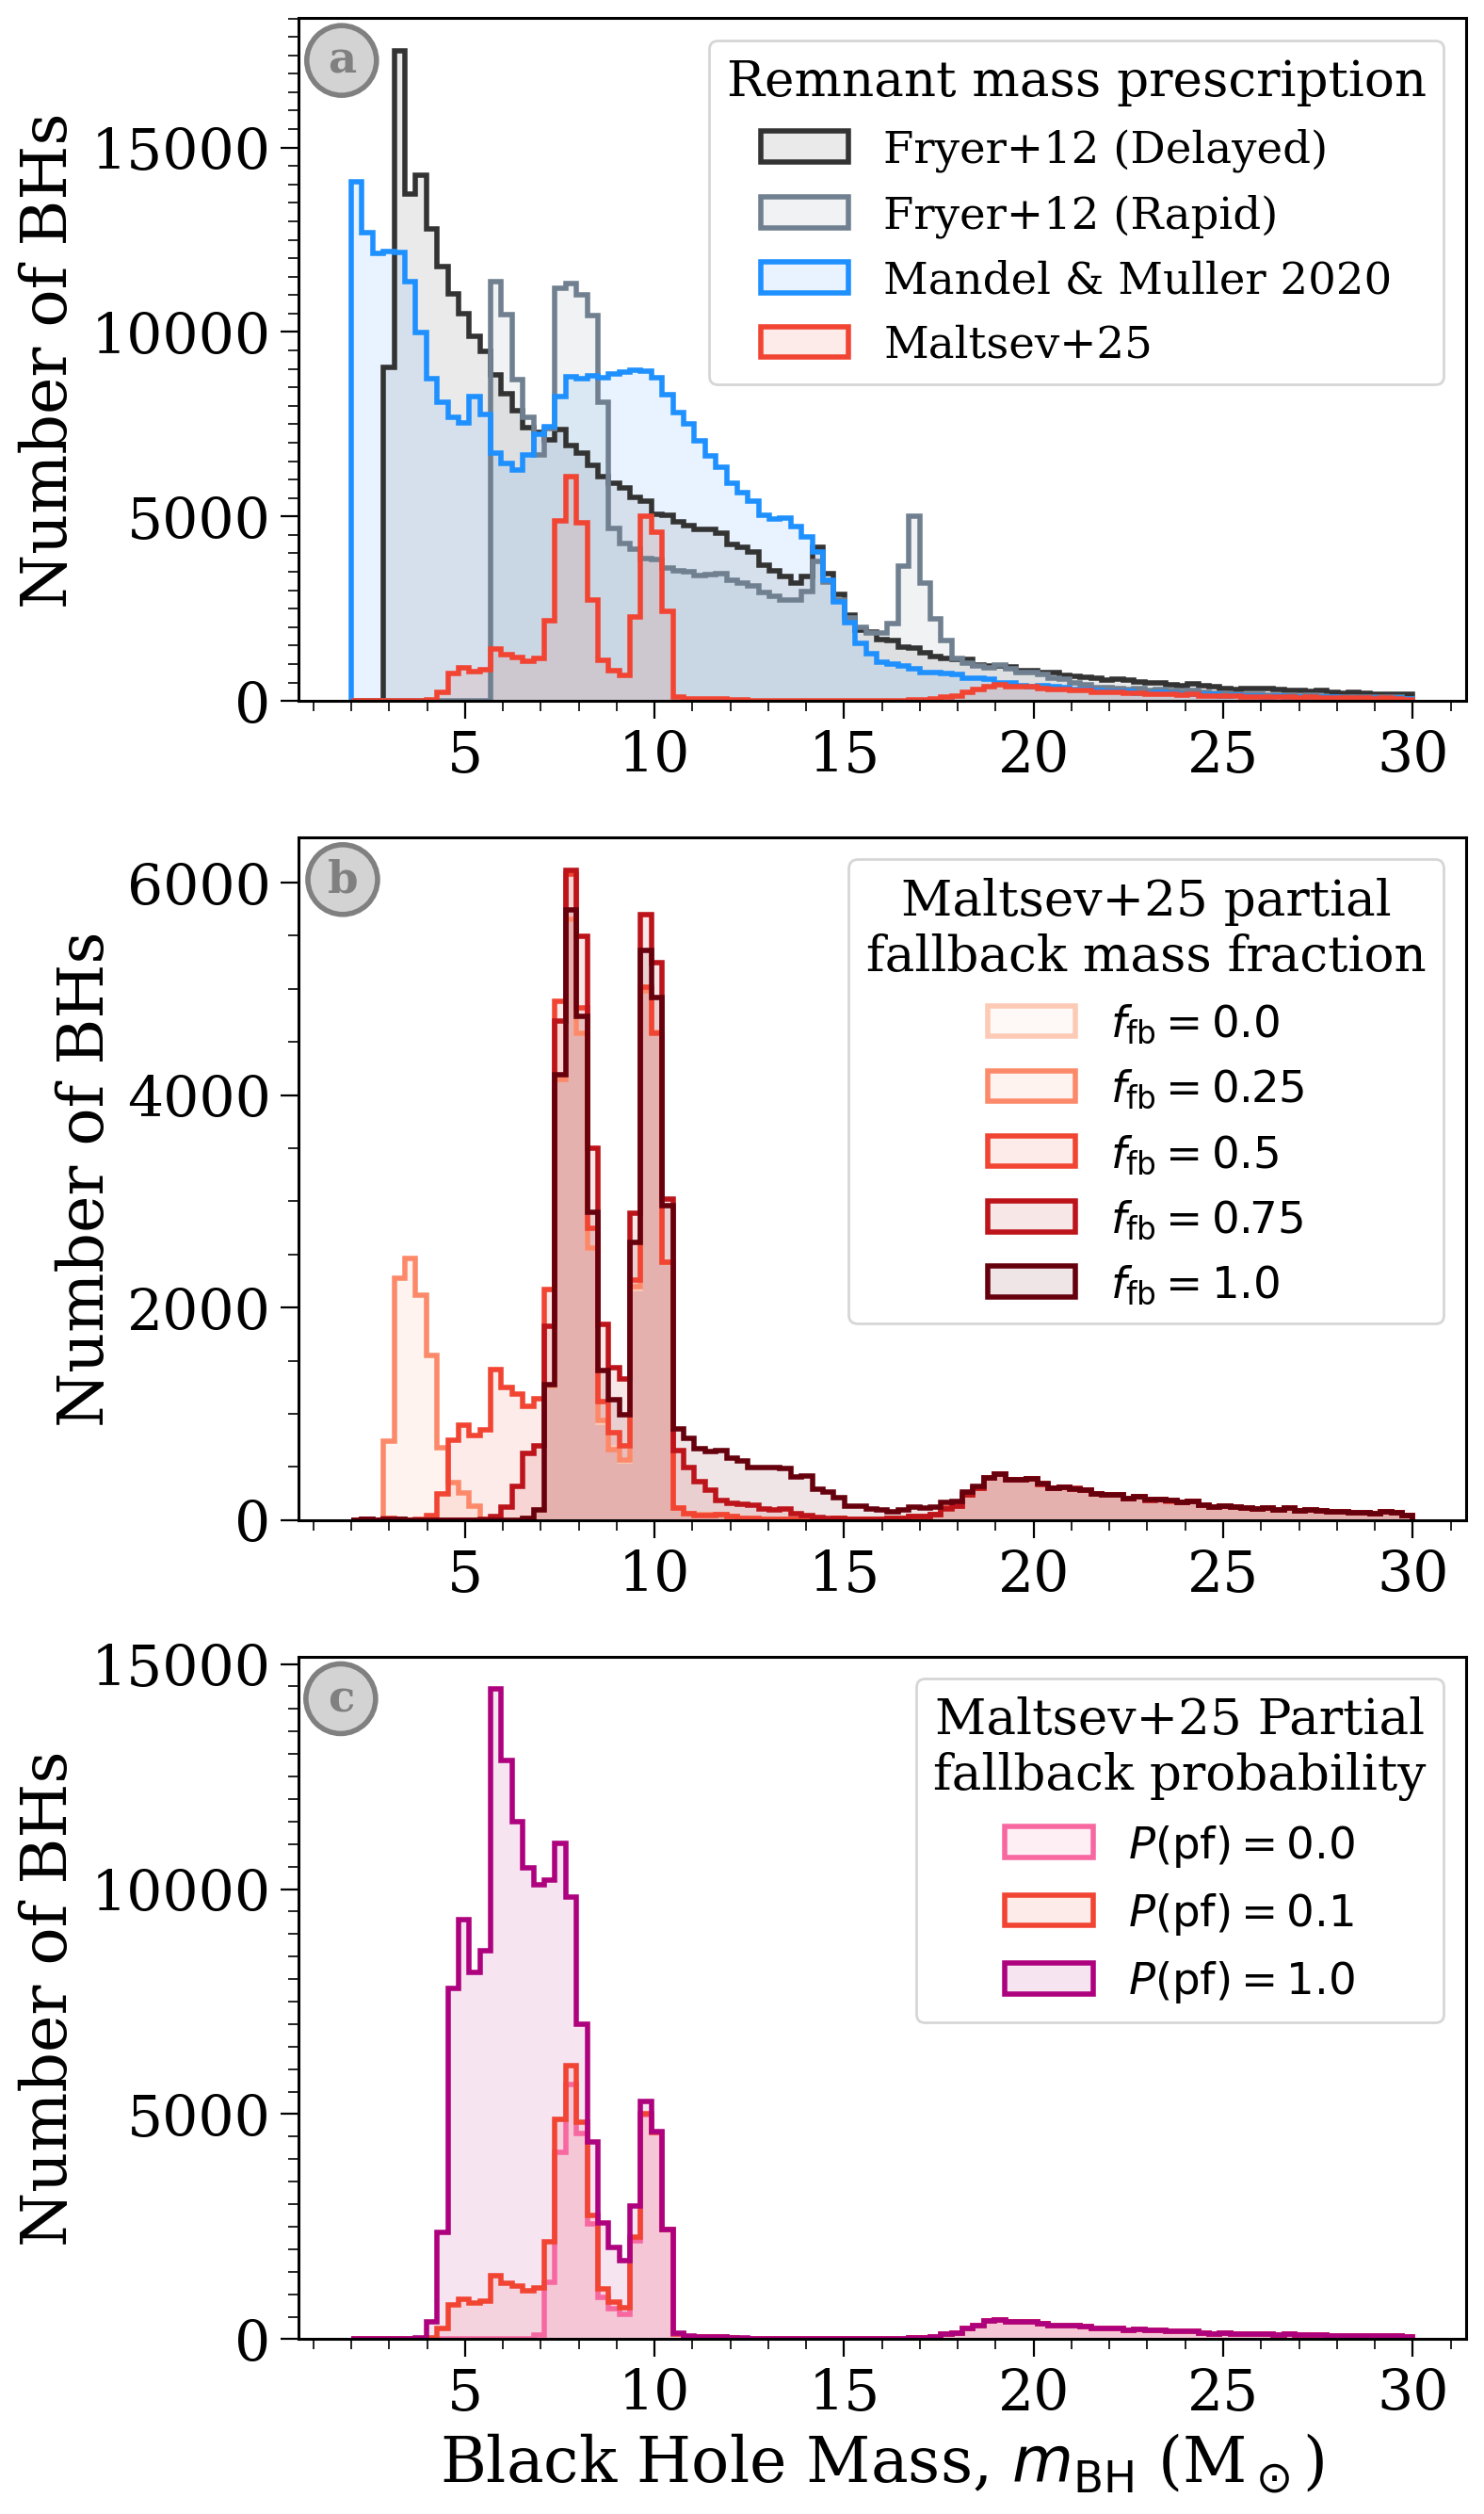

In [11]:
reload(plotting)

fig, axes = plt.subplots(3, 1, figsize=(8, 16))

BINS = np.linspace(2, 30, 100)

plotting.plot_mass_histogram(
    pops=[p for p in pops if ("Maltsev" not in p.label or "fb}=0.5" in p.label)],
    labels=["Fryer+12 (Delayed)", "Fryer+12 (Rapid)", "Mandel & Muller 2020", "Maltsev+25"],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"",
    ylabel=r"Number of BHs",
    alpha=0.1,
    legend_title="Remnant mass prescription",
    density=False,
    fig=fig,
    ax=axes[0],
    show=False
)

plotting.plot_mass_histogram(
    pops=[p for p in pops if "fb" in p.label],
    labels=[rf"$f_{{\rm fb}}={f}$" for f in [0.0, 0.25, 0.5, 0.75, 1.0]],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"",
    ylabel=r"Number of BHs",
    alpha=0.1,
    density=False,
    legend_title="Maltsev+25 partial\nfallback mass fraction",
    fig=fig,
    ax=axes[1],
    show=False
)

plotting.plot_mass_histogram(
    pops=[pops[-2], pops[5], pops[-1]],
    labels=[r"$P({\rm pf})=0.0$", r"$P({\rm pf})=0.1$", r"$P({\rm pf})=1.0$"],
    data=data,
    bins=BINS,
    co_type="BH",
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"Number of BHs",
    density=False,
    alpha=0.1,
    legend_title="Maltsev+25 Partial\nfallback probability",
    fig=fig,
    ax=axes[2],
    show=False
)

for let, ax in zip(["a", "b", "c"], axes):
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(500))

    ax.annotate(f"{let}", xy=(0.025, 0.97), xycoords='axes fraction', fontsize=0.7*fs, bbox=dict(boxstyle="circle", fc="lightgrey", ec="grey", lw=2), ha='left', va='top', color='grey', fontweight='bold')

plt.savefig("../plots/bh_mass_rm_variations.pdf", format="pdf", bbox_inches='tight')
plt.show()

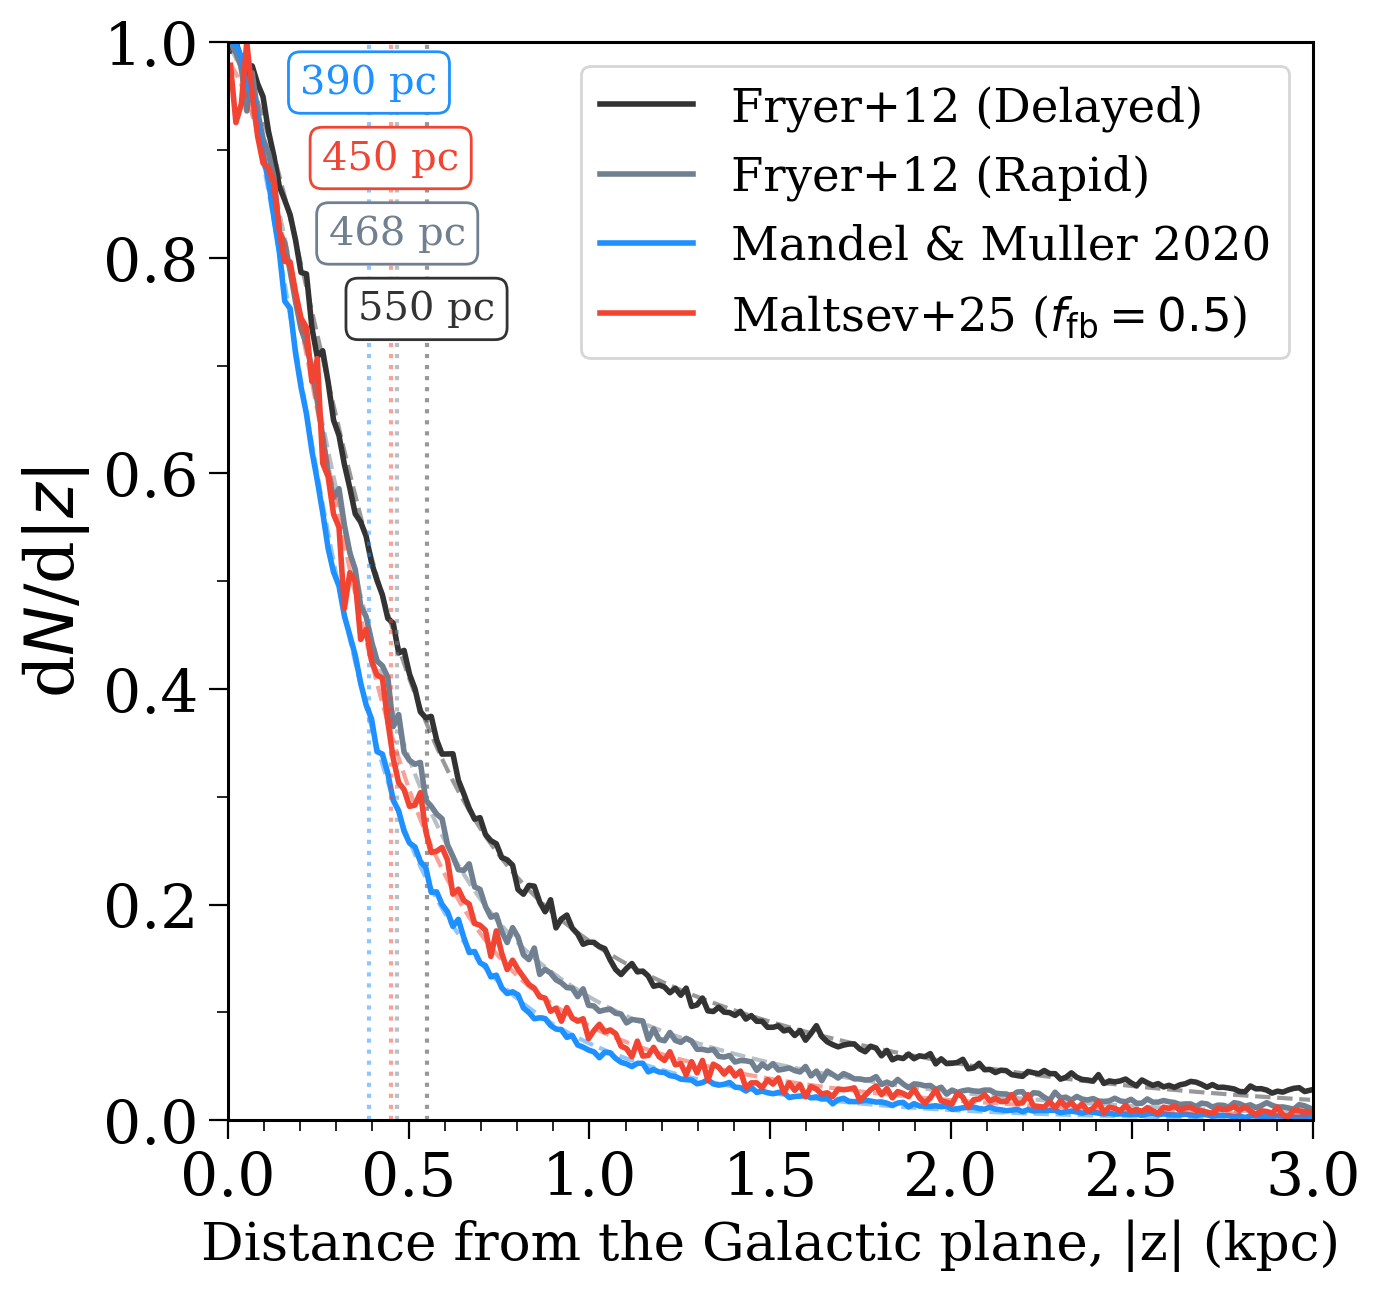

In [12]:
reload(plotting)
fig, ax = plt.subplots(figsize=(7, 7))

for pop, loc in zip([pops[0], pops[1], pops[2], pops[5]], [0.98 - 0.07 * 3, 0.98 - 0.07 * 2, 0.98 - 0.07 * 0, 0.98 - 0.07 * 1]):
    plotting.estimate_scale_height(
        z=data[pop.label]["pos"]["BH"][:, 2][~data[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=loc
    )


ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_rmp.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [13]:
n_bhs = []

for i, pop in enumerate(pops):
    scale_up = 6e10 / data[pop.label]["mass_binaries"]
    n_ns = len(data[pop.label]["bin_nums"]["NS"])
    n_bh = len(data[pop.label]["bin_nums"]["BH"])
    print(f"{pop.label}\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")
    print(f"  Scaled totals: {(n_ns + n_bh) * scale_up:1.1e}, NSs: {n_ns * scale_up:1.1e}, BHs: {n_bh * scale_up:1.1e}")
    n_bhs.append(n_bh * scale_up)

Fryer+12 (Delayed)
  Total: 1223037, NSs: 883903, BHs: 339134
  Scaled totals: 6.7e+08, NSs: 4.9e+08, BHs: 1.9e+08
Fryer+12 (Rapid)
  Total: 1176949, NSs: 954086, BHs: 222863
  Scaled totals: 6.5e+08, NSs: 5.3e+08, BHs: 1.2e+08
Mandel & Muller 2020
  Total: 1173859, NSs: 795224, BHs: 378635
  Scaled totals: 6.5e+08, NSs: 4.4e+08, BHs: 2.1e+08
Maltsev+25 ($f_{\rm fb}=0.0$)
  Total: 1178953, NSs: 1134452, BHs: 44501
  Scaled totals: 6.5e+08, NSs: 6.2e+08, BHs: 2.4e+07
Maltsev+25 ($f_{\rm fb}=0.25$)
  Total: 1178889, NSs: 1123813, BHs: 55076
  Scaled totals: 6.5e+08, NSs: 6.2e+08, BHs: 3.0e+07
Maltsev+25 ($f_{\rm fb}=0.5$)
  Total: 1178809, NSs: 1121676, BHs: 57133
  Scaled totals: 6.5e+08, NSs: 6.2e+08, BHs: 3.1e+07
Maltsev+25 ($f_{\rm fb}=0.75$)
  Total: 1178846, NSs: 1121642, BHs: 57204
  Scaled totals: 6.5e+08, NSs: 6.2e+08, BHs: 3.1e+07
Maltsev+25 ($f_{\rm fb}=1.0$)
  Total: 1178898, NSs: 1121901, BHs: 56997
  Scaled totals: 6.5e+08, NSs: 6.2e+08, BHs: 3.1e+07
Maltsev+25 ($P({\rm pf}

/tmp/ipykernel_1320880/1892890701.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace(" (", "\n(").replace("& ", "&\n") for l in labels], rotation=0, ha="center", fontsize=0.4*fs)


Text(5, 120000000.0, 'Olejak+20')

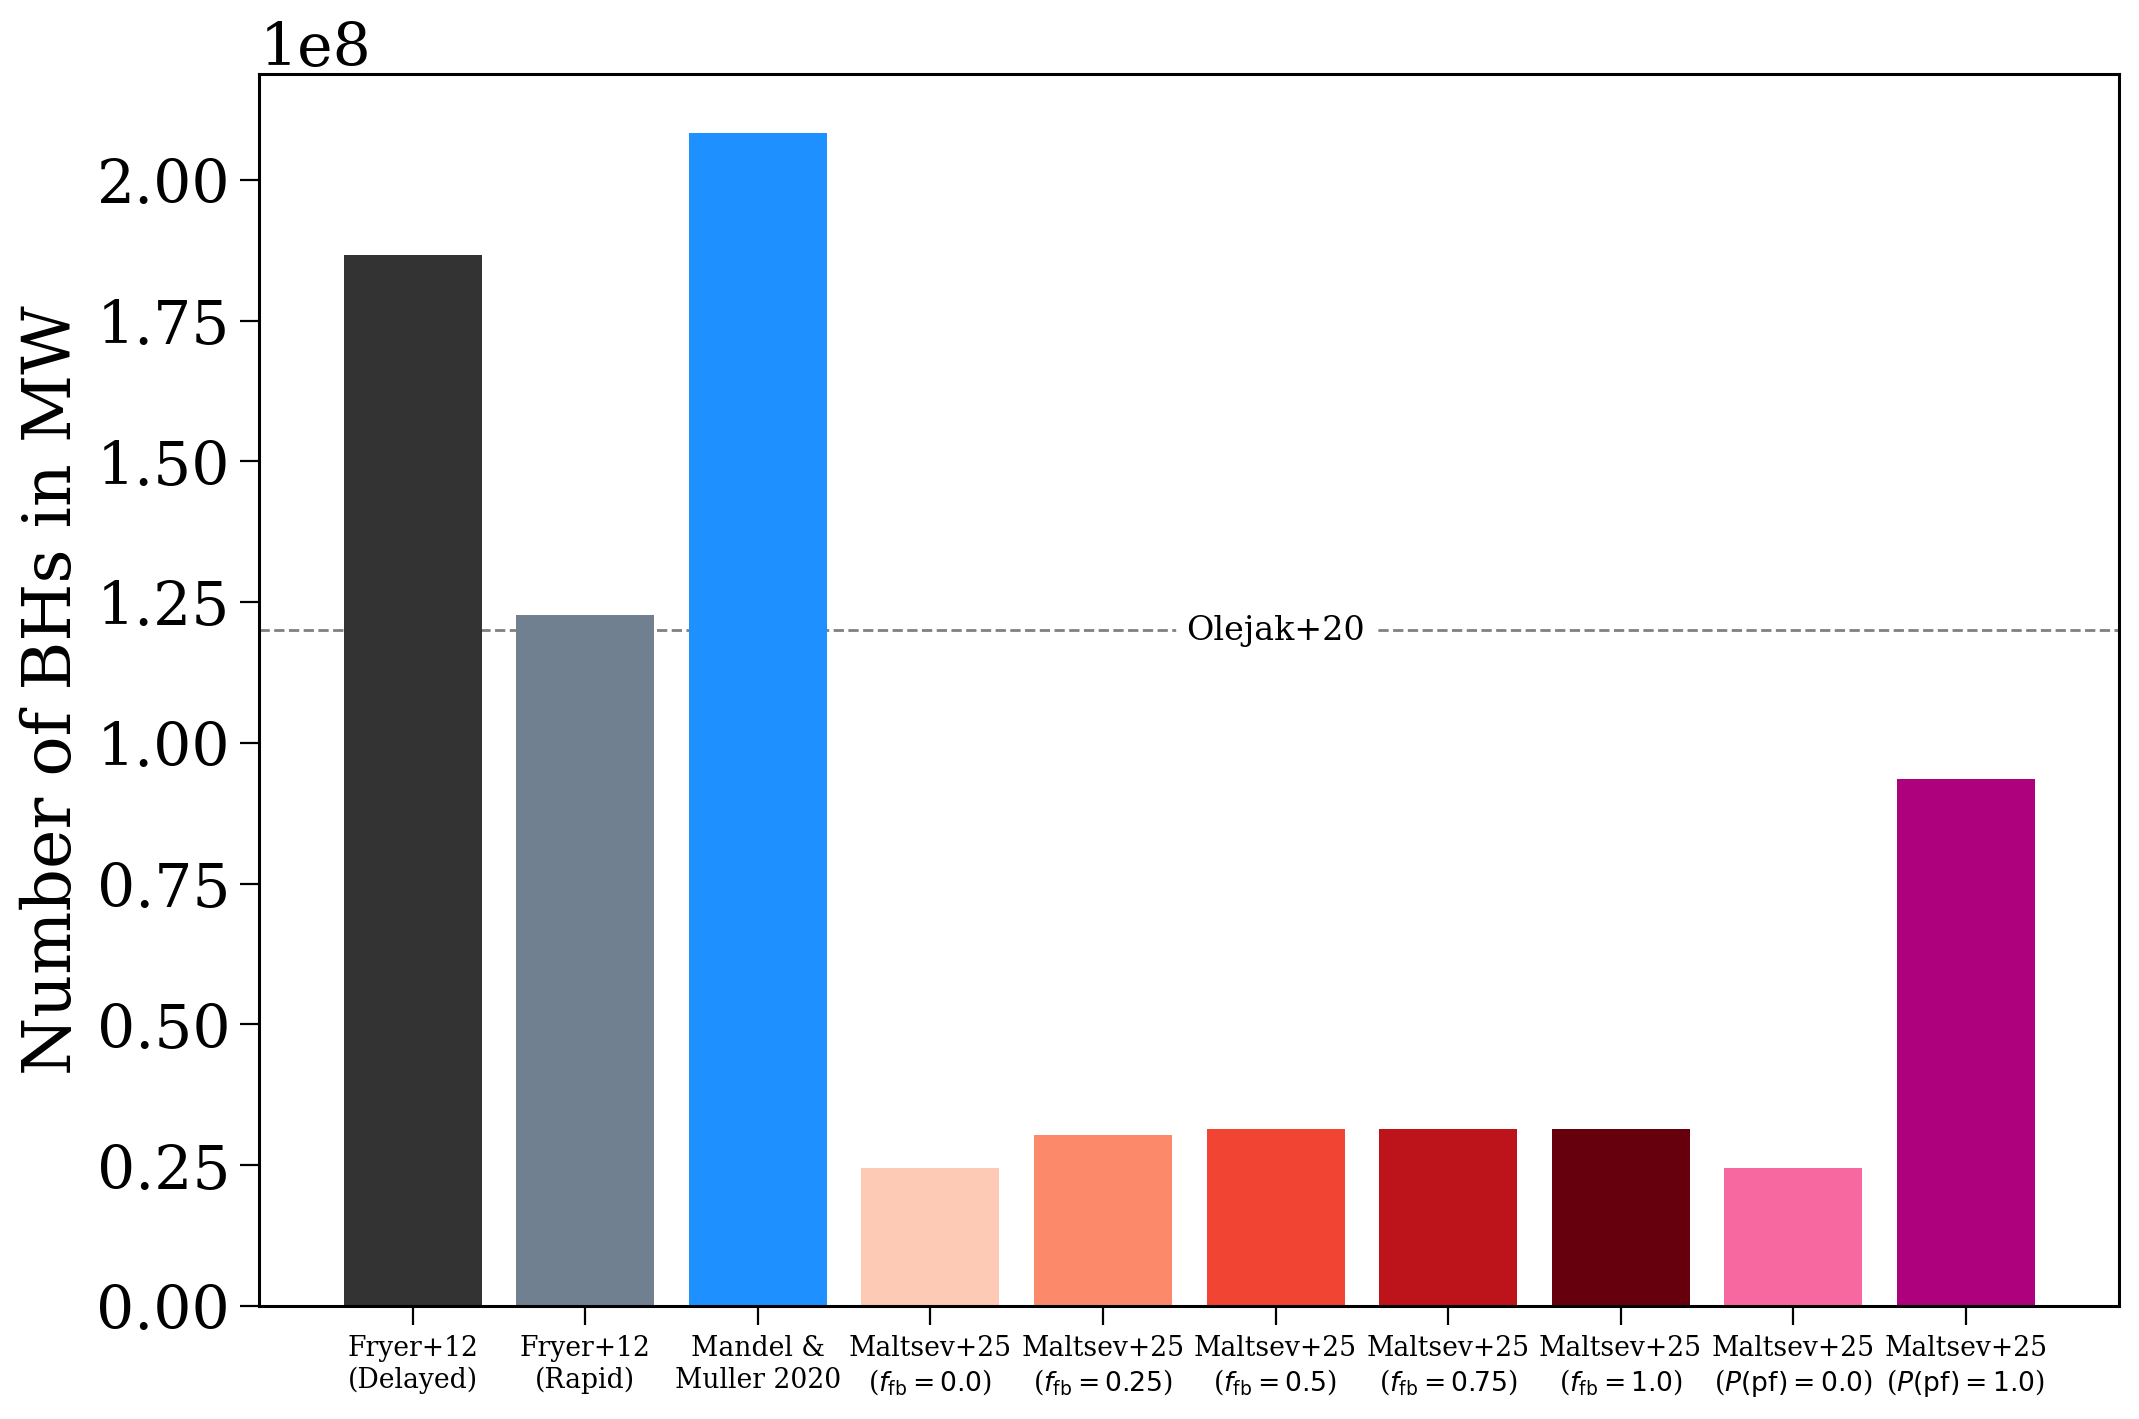

In [14]:
fig, ax = plt.subplots()

ax.bar(labels, n_bhs, color=colours)
ax.set_ylabel("Number of BHs in MW")

ax.set_xticklabels([l.replace(" (", "\n(").replace("& ", "&\n") for l in labels], rotation=0, ha="center", fontsize=0.4*fs)

ax.axhline(1.2e8, color='grey', linestyle='--', linewidth=1, zorder=-1)
ax.annotate("Olejak+20", xy=(5, 1.2e8), ha='center', va='center', fontsize=0.5*fs, bbox=dict(boxstyle="round", fc="white", ec="none"))

Inner 10 kpc
  Fryer+12 (Delayed) fraction within 0.5 kpc 0.52
  Fryer+12 (Rapid) fraction within 0.5 kpc 0.63
  Mandel & Muller 2020 fraction within 0.5 kpc 0.74
  Maltsev+25 ($f_{\rm fb}=0.0$) fraction within 0.5 kpc 0.75
  Maltsev+25 ($f_{\rm fb}=0.25$) fraction within 0.5 kpc 0.69
  Maltsev+25 ($f_{\rm fb}=0.5$) fraction within 0.5 kpc 0.68
  Maltsev+25 ($f_{\rm fb}=0.75$) fraction within 0.5 kpc 0.69
  Maltsev+25 ($f_{\rm fb}=1.0$) fraction within 0.5 kpc 0.74
  Maltsev+25 ($P({\rm pf})=0.0$) fraction within 0.5 kpc 0.75
  Maltsev+25 ($P({\rm pf})=1.0$) fraction within 0.5 kpc 0.49
Full population
  Fryer+12 (Delayed) fraction within 0.5 kpc 0.48
  Fryer+12 (Rapid) fraction within 0.5 kpc 0.61
  Mandel & Muller 2020 fraction within 0.5 kpc 0.74
  Maltsev+25 ($f_{\rm fb}=0.0$) fraction within 0.5 kpc 0.75
  Maltsev+25 ($f_{\rm fb}=0.25$) fraction within 0.5 kpc 0.66
  Maltsev+25 ($f_{\rm fb}=0.5$) fraction within 0.5 kpc 0.66
  Maltsev+25 ($f_{\rm fb}=0.75$) fraction within 0.5 kpc

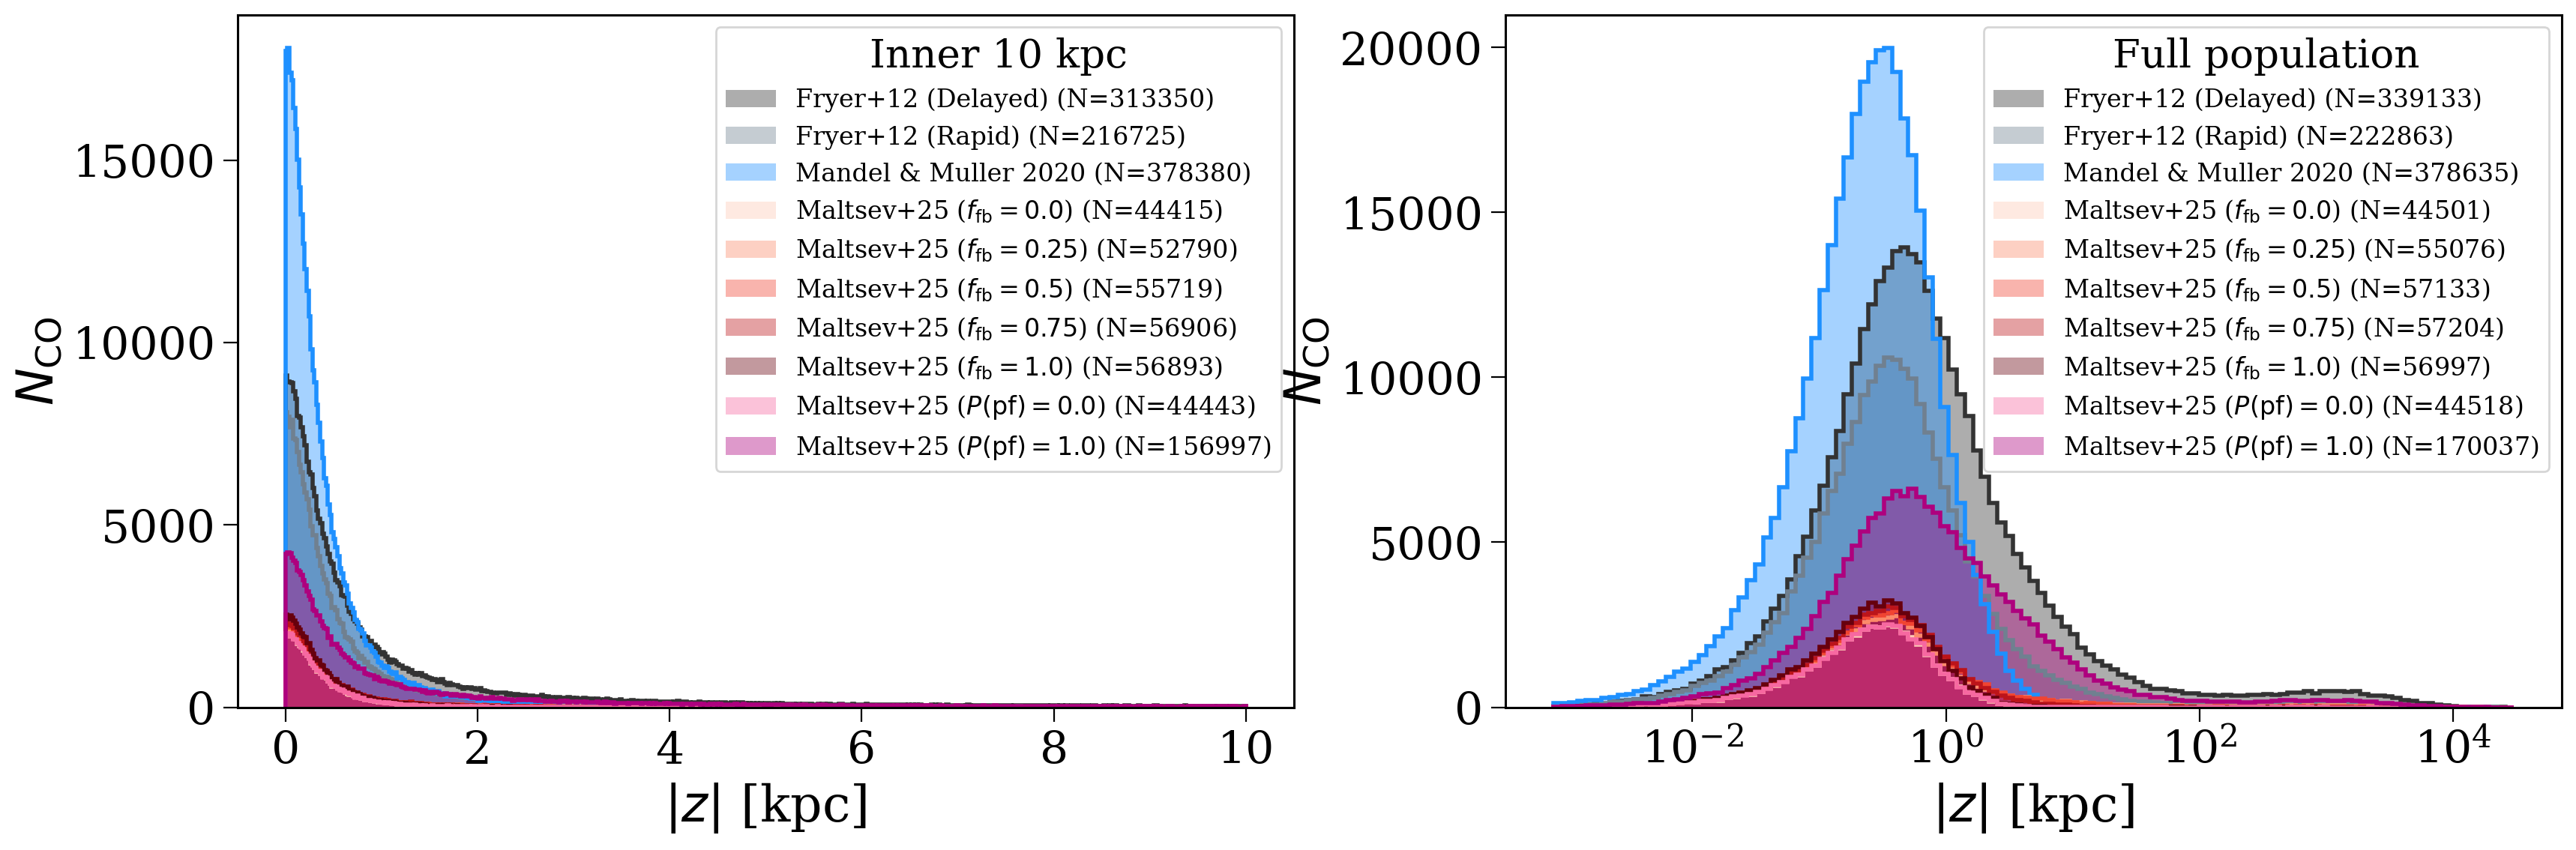

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [15]:
plotting.absolute_galactocentric_height(pops, data, co_type="BH")

In [16]:
print("Escaped fractions:")
for pop in pops:
    escaped = data[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {data[pop.label]["escaped"]["CO"].sum() / len(data[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {data[pop.label]["escaped"]["BH"].sum() / len(data[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {data[pop.label]["escaped"]["NS"].sum() / len(data[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Fryer+12 (Delayed):
      - CO = 0.105
      - BH = 0.029
      - NS = 0.134
  - Fryer+12 (Rapid):
      - CO = 0.112
      - BH = 0.009
      - NS = 0.137
  - Mandel & Muller 2020:
      - CO = 0.106
      - BH = 0.000
      - NS = 0.157
  - Maltsev+25 ($f_{\rm fb}=0.0$):
      - CO = 0.135
      - BH = 0.000
      - NS = 0.140
  - Maltsev+25 ($f_{\rm fb}=0.25$):
      - CO = 0.134
      - BH = 0.017
      - NS = 0.139
  - Maltsev+25 ($f_{\rm fb}=0.5$):
      - CO = 0.133
      - BH = 0.007
      - NS = 0.140
  - Maltsev+25 ($f_{\rm fb}=0.75$):
      - CO = 0.133
      - BH = 0.001
      - NS = 0.140
  - Maltsev+25 ($f_{\rm fb}=1.0$):
      - CO = 0.133
      - BH = 0.000
      - NS = 0.140
  - Maltsev+25 ($P({\rm pf})=0.0$):
      - CO = 0.135
      - BH = 0.000
      - NS = 0.140
  - Maltsev+25 ($P({\rm pf})=1.0$):
      - CO = 0.121
      - BH = 0.023
      - NS = 0.137


In [20]:
z_range = np.geomspace(0.1, 10, 1000)

abs_zs = [np.abs(data[pop.label]["pos"]["BH"][:, 2]) for pop in pops]

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=abs_zs + [np.abs(data["Fryer+12 (Delayed)"]["init_z"]["BH"])],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops] + [data["Fryer+12 (Delayed)"]["mass"]["BH"]],
    z_range=z_range,
    window_width=0.1
)

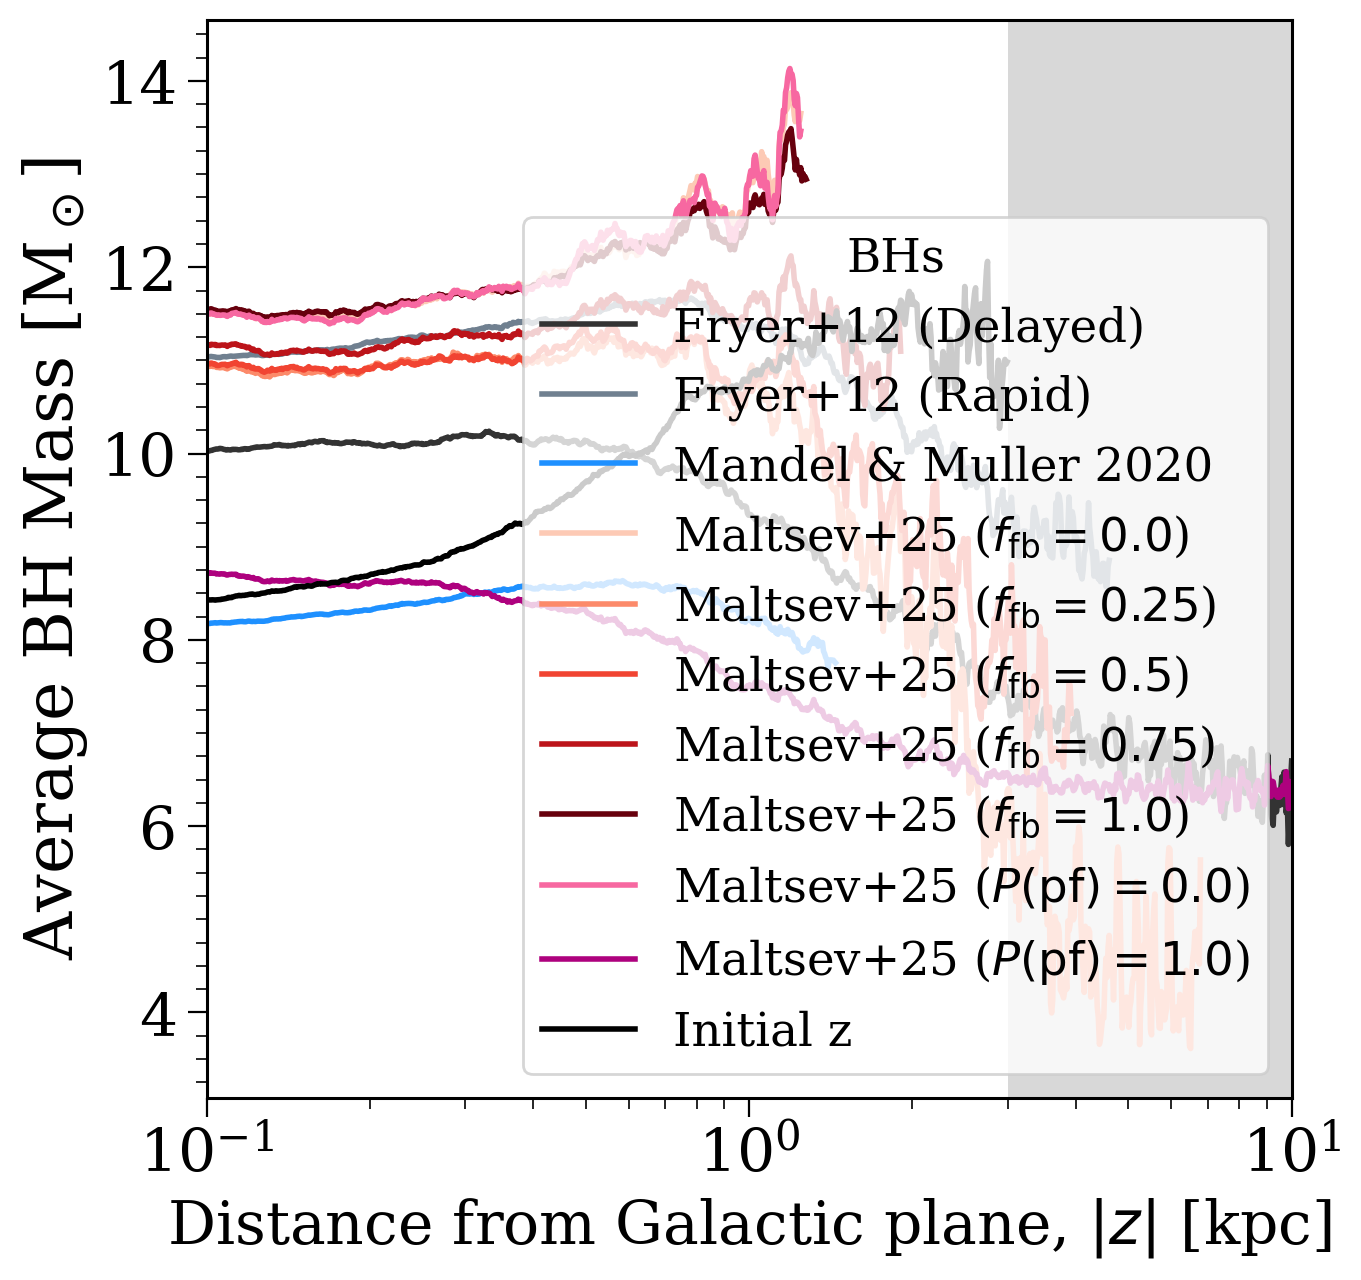

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Average BH Mass [M$_\\odot$]'>)

In [21]:
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses, labels=[pop.label for pop in pops] + ["Initial z"], colours=[pop.colour for pop in pops] + ["k"],
    z_maxes=[np.percentile(abs_zs[i], 95) for i in range(len(pops))] + [3], z_range=z_range
)